In [2]:
import math
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)

# Model setup and parameterization

## HealthPark Medical Center nexus

In [3]:
power_chain_nodes = [
    "PP_1_failed",
    "SUB_1_failed",
    "SUB_2_failed",
    "SUB_3_failed",
    "SUB_4_failed",
    "SUB_5_failed",
]

power_chain_edges = [
    {
        "parent": parent,
        "child": child,
        "relationship": "Sequential power delivery chain from plant through substations to HealthPark Medical Center",
    }
    for parent, child in zip(power_chain_nodes[:-1], power_chain_nodes[1:])
]

dependency_edges = pd.DataFrame(
    # Power chain edges
    power_chain_edges
    + [
        {"parent": "SUB_5_failed", "child": "Generator_activated", "relationship": "Tier 1 generator activates when final upstream substation service is unavailable"},
        {"parent": "Generator_activated", "child": "ElectricalDistribution_failed", "relationship": "Generator buffers power outage for 6.3 days"},

        # Water supply edges
        {"parent": "WTP_1_failed", "child": "WaterDistribution_failed", "relationship": "Shared water provider without backup"},

        # Communication edges
        {"parent": "LEE_DARK_FIBER_failed", "child": "Communication_Tier1_failed", "relationship": "Tier 1 primary communications"},
        {"parent": "LUMEN_MPLS_failed", "child": "Communication_Tier1_failed", "relationship": "Tier 1 backup communications"},
        {"parent": "COMCAST_ENS_failed", "child": "Communication_Tier1_failed", "relationship": "Tier 1 backup communications"},
        {"parent": "LUMEN_MPLS_failed", "child": "Communication_Tier2_failed", "relationship": "Tier 2 communications"},
        {"parent": "COMCAST_ENS_failed", "child": "Communication_Tier2_failed", "relationship": "Tier 2 communications"},
        {"parent": "LUMEN_MPLS_failed", "child": "Communication_Tier3_failed", "relationship": "Tier 3 primary communications"},
        {"parent": "COMCAST_BUSINESS_failed", "child": "Communication_Tier3_failed", "relationship": "Tier 3 backup communications"},
        {"parent": "TMOBILE_5G_failed", "child": "Communication_Tier3_failed", "relationship": "Tier 3 backup communications"},

        # Transportation edges
        {"parent": "roads_bridges_closure", "child": "Operations_capability_reduced", "relationship": "Reduced operations capability due to transportation disruptions for staff and supplies"},

        # Internal utility dependencies
        {"parent": "ElectricalDistribution_failed", "child": "WaterDistribution_failed", "relationship": "Internal utility dependency between electrical and water distribution"},

        # Tier functionality dependencies
        {"parent": "ElectricalDistribution_failed", "child": "Tier1_failed", "relationship": "Tier 1 functionality dependency"},
        {"parent": "WaterDistribution_failed", "child": "Tier1_failed", "relationship": "Tier 1 functionality dependency"},
        {"parent": "Communication_Tier1_failed", "child": "Tier1_failed", "relationship": "Tier 1 functionality dependency"},
        {"parent": "Operations_capability_reduced", "child": "Tier1_failed", "relationship": "Tier 1 functionality dependency"},

        {"parent": "ElectricalDistribution_failed", "child": "Tier2_failed", "relationship": "Tier 2 functionality dependency"},
        {"parent": "WaterDistribution_failed", "child": "Tier2_failed", "relationship": "Tier 2 functionality dependency"},
        {"parent": "Communication_Tier2_failed", "child": "Tier2_failed", "relationship": "Tier 2 functionality dependency"},
        {"parent": "Operations_capability_reduced", "child": "Tier2_failed", "relationship": "Tier 2 functionality dependency"},

        {"parent": "ElectricalDistribution_failed", "child": "Tier3_failed", "relationship": "Tier 3 functionality dependency"},
        {"parent": "WaterDistribution_failed", "child": "Tier3_failed", "relationship": "Tier 3 functionality dependency"},
        {"parent": "Communication_Tier3_failed", "child": "Tier3_failed", "relationship": "Tier 3 functionality dependency"},
        {"parent": "Operations_capability_reduced", "child": "Tier3_failed", "relationship": "Tier 3 functionality dependency"}
    ]
)

G = nx.DiGraph()
G.add_edges_from(dependency_edges[["parent", "child"]].itertuples(index=False, name=None))

dependency_edges

,parent,child,relationship
0,PP_1_failed,SUB_1_failed,Sequential power delivery chain from plant thr...
1,SUB_1_failed,SUB_2_failed,Sequential power delivery chain from plant thr...
2,SUB_2_failed,SUB_3_failed,Sequential power delivery chain from plant thr...
3,SUB_3_failed,SUB_4_failed,Sequential power delivery chain from plant thr...
4,SUB_4_failed,SUB_5_failed,Sequential power delivery chain from plant thr...
5,SUB_5_failed,Generator_activated,Tier 1 generator activates when final upstream...
6,Generator_activated,ElectricalDistribution_failed,Generator buffers power outage for 6.3 days
7,WTP_1_failed,WaterDistribution_failed,Shared water provider without backup
8,LEE_DARK_FIBER_failed,Communication_Tier1_failed,Tier 1 primary communications
9,LUMEN_MPLS_failed,Communication_Tier1_failed,Tier 1 backup communications


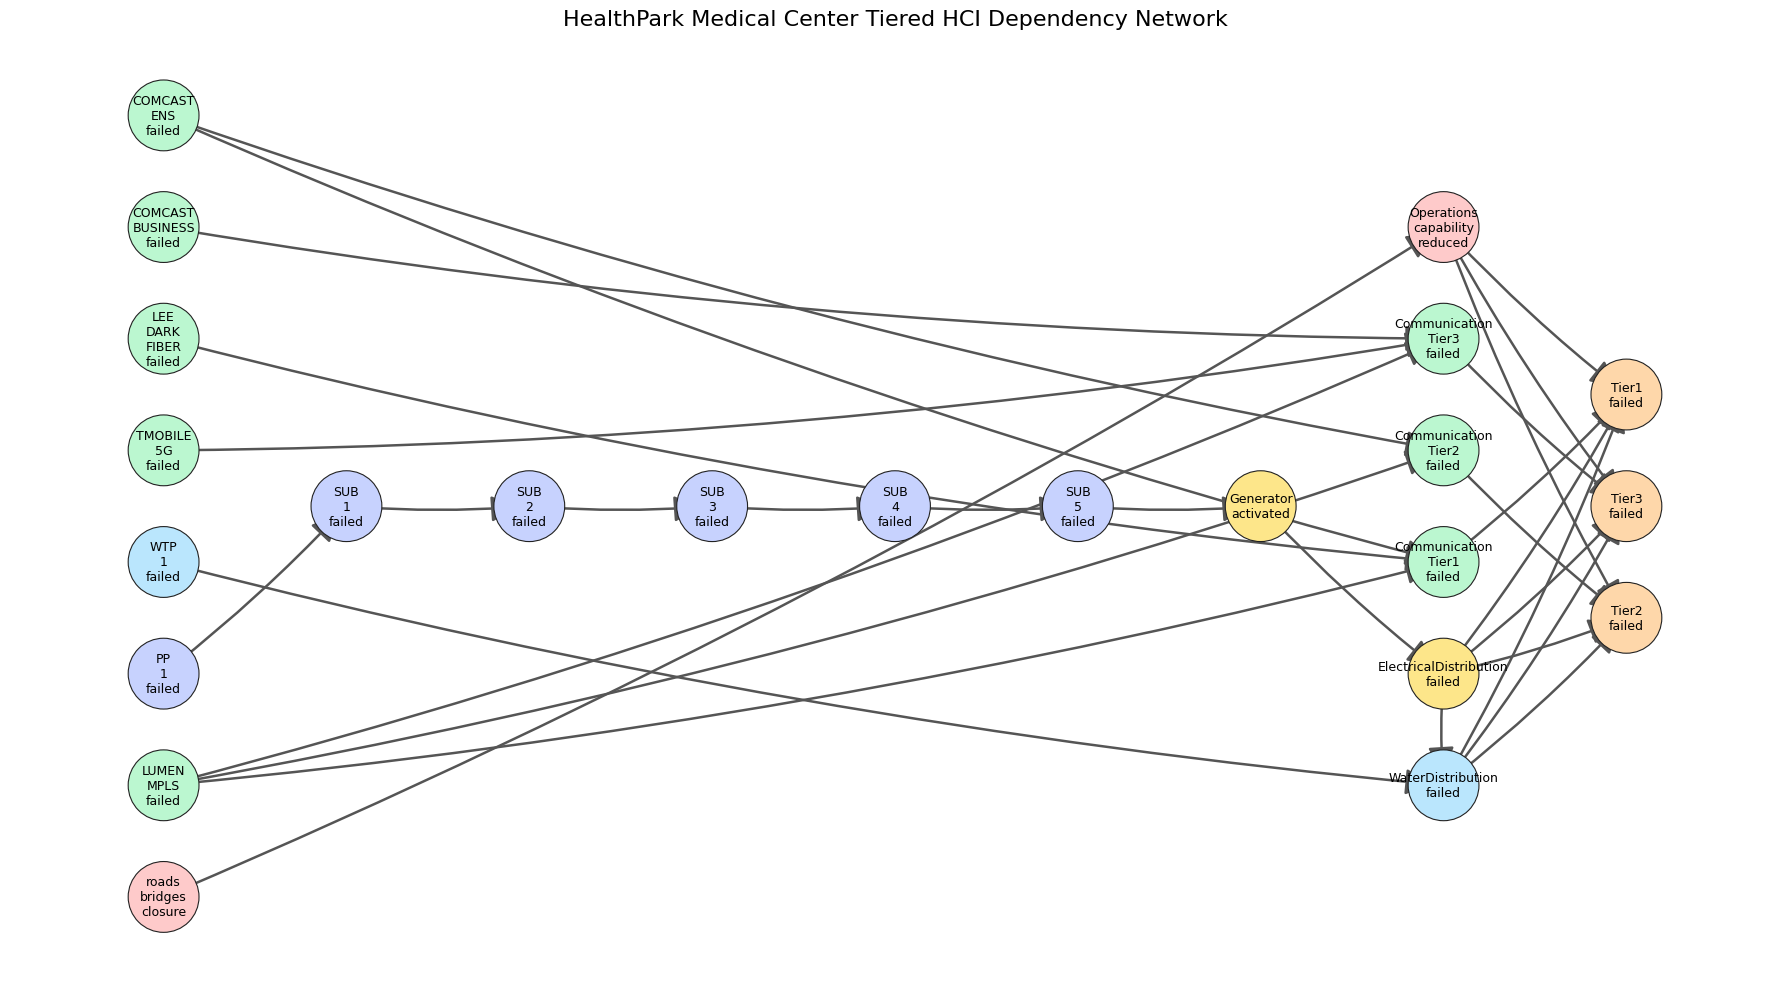

In [4]:
G = nx.DiGraph()
G.add_edges_from(dependency_edges[["parent", "child"]].itertuples(index=False, name=None))

layer_map = {
    "PP_1_failed": 0,
    "SUB_1_failed": 1,
    "SUB_2_failed": 2,
    "SUB_3_failed": 3,
    "SUB_4_failed": 4,
    "SUB_5_failed": 5,

    "WTP_1_failed": 0,
    "LEE_DARK_FIBER_failed": 0,
    "LUMEN_MPLS_failed": 0,
    "COMCAST_ENS_failed": 0,
    "COMCAST_BUSINESS_failed": 0,
    "TMOBILE_5G_failed": 0,
    "roads_bridges_closure": 0,

    "Generator_activated": 6,

    "ElectricalDistribution_failed": 7,

    "WaterDistribution_failed": 7,
    "Communication_Tier1_failed": 7,
    "Communication_Tier2_failed": 7,
    "Communication_Tier3_failed": 7,
    "Operations_capability_reduced": 7,

    "Tier1_failed": 8,
    "Tier2_failed": 8,
    "Tier3_failed": 8,
}

nx.set_node_attributes(G, layer_map, "layer")
pos = nx.multipartite_layout(G, subset_key="layer", align="vertical", scale=2.2)

node_colors = []
for node in G.nodes:
    if node.startswith("PP") or node.startswith("SUB"):
        node_colors.append("#c7d2fe")  # power chain
    elif "Generator" in node or "Electrical" in node:
        node_colors.append("#fde68a")  # electrical service
    elif "Water" in node or node.startswith("WTP"):
        node_colors.append("#bae6fd")  # water
    elif "Communication" in node or "FIBER" in node or "MPLS" in node or "COMCAST" in node or "TMOBILE" in node:
        node_colors.append("#bbf7d0")  # communications
    elif "roads" in node or "Operations" in node:
        node_colors.append("#fecaca")  # transportation / operations
    elif node.startswith("Tier"):
        node_colors.append("#fed7aa")  # hospital tiers
    else:
        node_colors.append("#e5e7eb")

plt.figure(figsize=(18, 10))
nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=40,
    width=1.8,
    edge_color="#555555",
    connectionstyle="arc3,rad=0.04",
)
nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=2600,
    edgecolors="#222222",
    linewidths=0.8,
)
nx.draw_networkx_labels(
    G,
    pos,
    labels={node: node.replace("_", "\n") for node in G.nodes},
    font_size=9,
)

plt.title("HealthPark Medical Center Tiered HCI Dependency Network", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()

## Rountine failure probability

In [5]:
# ---------------------------------------------------------------------
# Baseline routine failure probabilities
# ---------------------------------------------------------------------
# These are point-in-time probabilities estimated as failed hours / observed hours.
# Replace failed_hours with local logs when available.

routine_failure_logs = pd.DataFrame([
    # Power chain
    {"variable": "PP_1_failed", "observed_hours": 8760, "failed_hours": 1, "routine_p_failed": 1 / 8760, "source": "placeholder; rare non-hurricane plant/bulk supply outage"},
    {"variable": "SUB_1_failed", "observed_hours": 8760, "failed_hours": 4, "routine_p_failed": 4 / 8760, "source": "placeholder; substation/feeder outage"},
    {"variable": "SUB_2_failed", "observed_hours": 8760, "failed_hours": 4, "routine_p_failed": 4 / 8760, "source": "placeholder; substation/feeder outage"},
    {"variable": "SUB_3_failed", "observed_hours": 8760, "failed_hours": 4, "routine_p_failed": 4 / 8760, "source": "placeholder; substation/feeder outage"},
    {"variable": "SUB_4_failed", "observed_hours": 8760, "failed_hours": 4, "routine_p_failed": 4 / 8760, "source": "placeholder; substation/feeder outage"},
    {"variable": "SUB_5_failed", "observed_hours": 8760, "failed_hours": 4, "routine_p_failed": 4 / 8760, "source": "placeholder; final substation/feeder outage"},

    # Water
    {"variable": "WTP_1_failed", "observed_hours": 8760, "failed_hours": 2, "routine_p_failed": 2 / 8760, "source": "placeholder; water treatment operational interruption"},
    # {"variable": "WaterDistribution_failed", "observed_hours": 8760, "failed_hours": 1, "routine_p_failed": 1 / 8760, "source": "placeholder; distribution pressure/quality interruption"},

    # Communications
    {"variable": "LEE_DARK_FIBER_failed", "observed_hours": 8760, "failed_hours": 6, "routine_p_failed": 6 / 8760, "source": "placeholder; dark fiber interruption"},
    {"variable": "LUMEN_MPLS_failed", "observed_hours": 8760, "failed_hours": 6, "routine_p_failed": 6 / 8760, "source": "placeholder; MPLS provider interruption"},
    {"variable": "COMCAST_ENS_failed", "observed_hours": 8760, "failed_hours": 6, "routine_p_failed": 6 / 8760, "source": "placeholder; ENS provider interruption"},
    {"variable": "COMCAST_BUSINESS_failed", "observed_hours": 8760, "failed_hours": 6, "routine_p_failed": 6 / 8760, "source": "placeholder; business internet interruption"},
    {"variable": "TMOBILE_5G_failed", "observed_hours": 8760, "failed_hours": 6, "routine_p_failed": 6 / 8760, "source": "placeholder; wireless service interruption"},

    # Transportation
    {"variable": "roads_bridges_closure", "observed_hours": 8760, "failed_hours": 0, "routine_p_failed": 0 / 8760, "source": "placeholder; routine road/bridge closure"}
])

routine_probability_lookup = dict(zip(
    routine_failure_logs["variable"],
    routine_failure_logs["routine_p_failed"],
))

def p_routine(variable):
    return float(routine_probability_lookup.get(variable, 0.0))

routine_failure_logs

,variable,observed_hours,failed_hours,routine_p_failed,source
0,PP_1_failed,8760,1,0.000114,placeholder; rare non-hurricane plant/bulk sup...
1,SUB_1_failed,8760,4,0.000457,placeholder; substation/feeder outage
2,SUB_2_failed,8760,4,0.000457,placeholder; substation/feeder outage
3,SUB_3_failed,8760,4,0.000457,placeholder; substation/feeder outage
4,SUB_4_failed,8760,4,0.000457,placeholder; substation/feeder outage
5,SUB_5_failed,8760,4,0.000457,placeholder; final substation/feeder outage
6,WTP_1_failed,8760,2,0.000228,placeholder; water treatment operational inter...
7,LEE_DARK_FIBER_failed,8760,6,0.000685,placeholder; dark fiber interruption
8,LUMEN_MPLS_failed,8760,6,0.000685,placeholder; MPLS provider interruption
9,COMCAST_ENS_failed,8760,6,0.000685,placeholder; ENS provider interruption


## Fragility curves under flood depth

For HealthPark Medical Center:

- First floor elevation is 10 ft above sea level
- Generator plant finished floor elevation is 12 ft above sea level
- 8-10 ft surge may cause first-floor water intrusion
- 11-15 ft surge likely causes 1-4 ft water on first floor
- Above 15 ft likely causes more than 3 ft water on first floor

In [6]:
# ---------------------------------------------------------------------
# Threshold Logistic Fragility Curves
# ---------------------------------------------------------------------
#
# Logistic fragility model:
#
# F(D) = 0,                                  if D <= D0
# F(D) = 1 / (1 + (s / (D - D0)) ** n),      if D > D0
#
# where:
# D  = flood elevation above sea level, ft
# D0 = category-specific zero-failure threshold, ft
# s  = scale parameter
# n  = shape/slope parameter
# ---------------------------------------------------------------------

FT_TO_M = 0.3048

HOSPITAL_FIRST_FLOOR_ELEVATION_FT = 10.0
GENERATOR_PLANT_FLOOR_ELEVATION_FT = 12.0


def logistic_fragility_with_threshold(flood_elevation_ft, threshold_ft, s, n):
    """
    Threshold logistic fragility model.

    F(D) = 0, if D <= threshold
    F(D) = 1 / (1 + (s / (D - threshold)) ** n), if D > threshold

    flood_elevation_ft: flood elevation above sea level, ft
    threshold_ft: zero-failure threshold, ft
    s: scale parameter
    n: shape/slope parameter
    """
    effective_demand = flood_elevation_ft - threshold_ft

    if effective_demand <= 0:
        return 0.0

    return 1.0 / (1.0 + (s / effective_demand) ** n)


def combine_independent_probabilities(*probabilities):
    survival = 1.0
    for p in probabilities:
        survival *= 1.0 - float(p)
    return 1.0 - survival


# ---------------------------------------------------------------------
# Category-level fragility parameters
# ---------------------------------------------------------------------
# Different categories use the same model form but different threshold,
# scale, and slope parameters.
# ---------------------------------------------------------------------

fragility_parameters = pd.DataFrame([
    {
        "node_category": "PowerPlant",
        "threshold_ft": 14.0,
        "s": 7.0,
        "n": 3.0,
        "basis": "Low probability below 8 ft; gradual increase for large power asset exposure.",
    },
    {
        "node_category": "Substation",
        "threshold_ft": 10.0,
        "s": 5.0,
        "n": 3.2,
        "basis": "Electrical equipment vulnerability increases after threshold flood exposure.",
    },
    {
        "node_category": "WaterTreatmentPlant",
        "threshold_ft": 8.0,
        "s": 5.0,
        "n": 2.8,
        "basis": "Water utility disruption can begin around road/access, pumps, controls, and low-lying distribution exposure; probability remains low below threshold.",
    },
    {
        "node_category": "Communication",
        "threshold_ft": 8.0,
        "s": 5.5,
        "n": 2.7,
        "basis": "Communication cabinets, hubs, power, and backhaul become vulnerable above threshold.",
    },
    {
        "node_category": "Transportation",
        "threshold_ft": 8.0,
        "s": 4.0,
        "n": 2.8,
        "basis": "Road and bridge closure probability increases as flood elevation restricts access.",
    },
    {
        "node_category": "Generator",
        "threshold_ft": 11.0,
        "s": 3.0,
        "n": 3.5,
        "basis": "HealthPark note: generator/switchgear may become inoperable at 12-15 ft storm surge.",
    },
    {
        "node_category": "Hospital",
        "threshold_ft": 8.0,
        "s": 4.0,
        "n": 3.0,
        "basis": "HealthPark note: possible intrusion near 9-10 ft; likely water on first floor at 11-15 ft.",
    },
])

fragility_parameters["threshold_m"] = fragility_parameters["threshold_ft"] * FT_TO_M
fragility_parameters["s_m"] = fragility_parameters["s"] * FT_TO_M

fragility_parameters

,node_category,threshold_ft,s,n,basis,threshold_m,s_m
0,PowerPlant,14.0,7.0,3.0,Low probability below 8 ft; gradual increase f...,4.2672,2.1336
1,Substation,10.0,5.0,3.2,Electrical equipment vulnerability increases a...,3.0480,1.5240
2,WaterTreatmentPlant,8.0,5.0,2.8,Water utility disruption can begin around road...,2.4384,1.5240
3,Communication,8.0,5.5,2.7,"Communication cabinets, hubs, power, and backh...",2.4384,1.6764
4,Transportation,8.0,4.0,2.8,Road and bridge closure probability increases ...,2.4384,1.2192
5,Generator,11.0,3.0,3.5,HealthPark note: generator/switchgear may beco...,3.3528,0.9144
6,Hospital,8.0,4.0,3.0,HealthPark note: possible intrusion near 9-10 ...,2.4384,1.2192


In [7]:
# ---------------------------------------------------------------------
# Node-to-category mapping
# ---------------------------------------------------------------------
# Important:
# Generator_activated is not a failure node. It is triggered by upstream grid loss.
# The flood vulnerability of generator/switchgear is represented through
# ElectricalDistribution_failed.
# ---------------------------------------------------------------------

node_category_lookup = {
    "PP_1_failed": "PowerPlant",

    "SUB_1_failed": "Substation",
    "SUB_2_failed": "Substation",
    "SUB_3_failed": "Substation",
    "SUB_4_failed": "Substation",
    "SUB_5_failed": "Substation",

    "WTP_1_failed": "WaterTreatmentPlant",

    "LEE_DARK_FIBER_failed": "Communication",
    "LUMEN_MPLS_failed": "Communication",
    "COMCAST_ENS_failed": "Communication",
    "COMCAST_BUSINESS_failed": "Communication",
    "TMOBILE_5G_failed": "Communication",

    "roads_bridges_closure": "Transportation",

    "ElectricalDistribution_failed": "Generator",

    "Tier1_failed": "Hospital",
    "Tier2_failed": "Hospital",
    "Tier3_failed": "Hospital",
}

In [8]:
# ---------------------------------------------------------------------
# Failure probability helper functions
# ---------------------------------------------------------------------

def p_flood_failure_by_category(node_category, flood_elevation_ft):
    row = fragility_parameters.loc[
        fragility_parameters["node_category"] == node_category
    ].iloc[0]

    return logistic_fragility_with_threshold(
        flood_elevation_ft=flood_elevation_ft,
        threshold_ft=row["threshold_ft"],
        s=row["s"],
        n=row["n"],
    )


def p_flood_failure(variable, flood_elevation_ft):
    node_category = node_category_lookup[variable]
    return p_flood_failure_by_category(node_category, flood_elevation_ft)


def p_total_failure(variable, flood_elevation_ft):
    p_flood = p_flood_failure(variable, flood_elevation_ft)
    p_base = p_routine(variable)
    return combine_independent_probabilities(p_flood, p_base)

In [9]:
# ---------------------------------------------------------------------
# Calibration table
# ---------------------------------------------------------------------

calibration_flood_levels_ft = [0, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 18]

fragility_calibration_table = pd.DataFrame([
    {
        "node_category": row["node_category"],
        "threshold_ft": row["threshold_ft"],
        "flood_elevation_ft": flood_ft,
        "p_flood_failure": logistic_fragility_with_threshold(
            flood_elevation_ft=flood_ft,
            threshold_ft=row["threshold_ft"],
            s=row["s"],
            n=row["n"],
        ),
    }
    for _, row in fragility_parameters.iterrows()
    for flood_ft in calibration_flood_levels_ft
])

display(
    fragility_calibration_table.pivot(
        index="flood_elevation_ft",
        columns="node_category",
        values="p_flood_failure",
    ).round(3)
)

node_category,Communication,Generator,Hospital,PowerPlant,Substation,Transportation,WaterTreatmentPlant
flood_elevation_ft,,,,,,,
0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
5,0.000,0.000,0.000,0.000,0.000,0.000,0.000
6,0.000,0.000,0.000,0.000,0.000,0.000,0.000
7,0.000,0.000,0.000,0.000,0.000,0.000,0.000
8,0.000,0.000,0.000,0.000,0.000,0.000,0.000
9,0.010,0.000,0.015,0.000,0.000,0.020,0.011
10,0.061,0.000,0.111,0.000,0.000,0.126,0.071
11,0.163,0.000,0.297,0.000,0.006,0.309,0.193
12,0.297,0.021,0.500,0.000,0.051,0.500,0.349


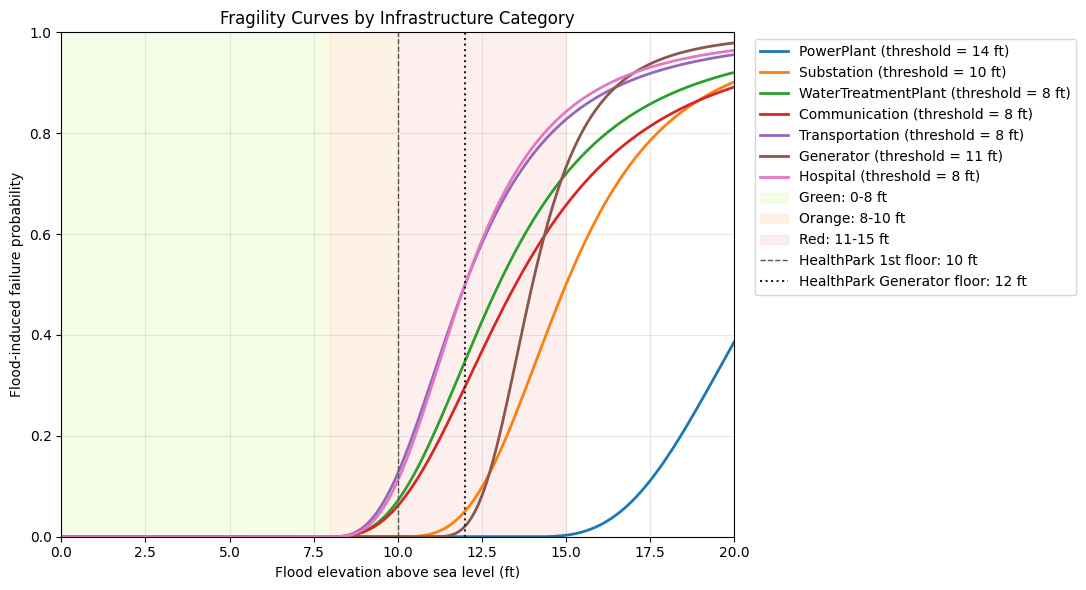

In [10]:
# ---------------------------------------------------------------------
# Plot fragility curves
# ---------------------------------------------------------------------

flood_grid_ft = np.linspace(0, 20, 400)

plt.figure(figsize=(11, 6))

for _, row in fragility_parameters.iterrows():
    probs = [
        logistic_fragility_with_threshold(
            flood_elevation_ft=d,
            threshold_ft=row["threshold_ft"],
            s=row["s"],
            n=row["n"],
        )
        for d in flood_grid_ft
    ]

    plt.plot(
        flood_grid_ft,
        probs,
        linewidth=2,
        label=f"{row['node_category']} (threshold = {row['threshold_ft']:.0f} ft)",
    )

plt.axvspan(0, 8, color="#d9f99d", alpha=0.25, label="Green: 0-8 ft")
plt.axvspan(8, 10, color="#fed7aa", alpha=0.30, label="Orange: 8-10 ft")
plt.axvspan(10, 15, color="#fecaca", alpha=0.30, label="Red: 11-15 ft")
plt.axvline(10, color="#555555", linestyle="--", linewidth=1, label="HealthPark 1st floor: 10 ft")
plt.axvline(12, color="#222222", linestyle=":", linewidth=1.5, label="HealthPark Generator floor: 12 ft")

plt.xlabel("Flood elevation above sea level (ft)")
plt.ylabel("Flood-induced failure probability")
plt.title("Fragility Curves by Infrastructure Category")
plt.ylim(0, 1)
plt.xlim(0, 20)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Uncertainty range

- threshold_ft: +/- 0.5 to 2.0 ft depending on category knowledge
- s: +/- 20% to 35%
- n: +/- 15% to 30%

In [11]:
# ---------------------------------------------------------------------
# Fragility parameter uncertainty ranges
# ---------------------------------------------------------------------
# These ranges are centered around your revised fragility_parameters.
#
# threshold_ft:
#   uncertainty in the flood elevation where failure probability begins
#
# s:
#   uncertainty in the scale/effective demand parameter
#
# n:
#   uncertainty in the slope/shape parameter
# ---------------------------------------------------------------------

fragility_uncertainty_ranges = pd.DataFrame([
    {
        "node_category": "PowerPlant",
        "threshold_ft_low": 12.0,
        "threshold_ft_high": 15.0,
        "s_low": 5.5,
        "s_high": 9.0,
        "n_low": 2.2,
        "n_high": 3.8,
        "basis": "PowerPlant threshold is highly uncertain because site-specific plant elevation/protection is not calibrated.",
    },
    {
        "node_category": "Substation",
        "threshold_ft_low": 9.0,
        "threshold_ft_high": 11.0,
        "s_low": 4.0,
        "s_high": 6.5,
        "n_low": 2.4,
        "n_high": 4.0,
        "basis": "Substation exposure is uncertain but less broad than power plant because electrical vulnerability begins near major surge levels.",
    },
    {
        "node_category": "WaterTreatmentPlant",
        "threshold_ft_low": 7.5,
        "threshold_ft_high": 9.5,
        "s_low": 4.0,
        "s_high": 6.5,
        "n_low": 2.1,
        "n_high": 3.6,
        "basis": "Water utility exposure depends on pumps, controls, distribution pressure, protection, and site access.",
    },
    {
        "node_category": "Communication",
        "threshold_ft_low": 7.0,
        "threshold_ft_high": 9.0,
        "s_low": 4.2,
        "s_high": 7.2,
        "n_low": 2.0,
        "n_high": 3.5,
        "basis": "Communication vulnerability depends on cabinets, hubs, local power, backhaul, and backup power.",
    },
    {
        "node_category": "Transportation",
        "threshold_ft_low": 7.0,
        "threshold_ft_high": 9.0,
        "s_low": 3.0,
        "s_high": 5.5,
        "n_low": 2.0,
        "n_high": 3.6,
        "basis": "Transportation closure threshold is uncertain because road elevations and closure decisions vary spatially.",
    },
    {
        "node_category": "Generator",
        "threshold_ft_low": 10.5,
        "threshold_ft_high": 12.0,
        "s_low": 2.2,
        "s_high": 4.0,
        "n_low": 2.6,
        "n_high": 4.5,
        "basis": "HealthPark note anchors generator/switchgear concern around 12-15 ft surge, so uncertainty is narrower.",
    },
    {
        "node_category": "Hospital",
        "threshold_ft_low": 7.5,
        "threshold_ft_high": 9.0,
        "s_low": 3.0,
        "s_high": 5.5,
        "n_low": 2.2,
        "n_high": 3.8,
        "basis": "HealthPark note anchors first-floor intrusion near 9-10 ft and likely water at 11-15 ft.",
    },
])

fragility_uncertainty_ranges

,node_category,threshold_ft_low,threshold_ft_high,s_low,s_high,n_low,n_high,basis
0,PowerPlant,12.0,15.0,5.5,9.0,2.2,3.8,PowerPlant threshold is highly uncertain becau...
1,Substation,9.0,11.0,4.0,6.5,2.4,4.0,Substation exposure is uncertain but less broa...
2,WaterTreatmentPlant,7.5,9.5,4.0,6.5,2.1,3.6,"Water utility exposure depends on pumps, contr..."
3,Communication,7.0,9.0,4.2,7.2,2.0,3.5,Communication vulnerability depends on cabinet...
4,Transportation,7.0,9.0,3.0,5.5,2.0,3.6,Transportation closure threshold is uncertain ...
5,Generator,10.5,12.0,2.2,4.0,2.6,4.5,HealthPark note anchors generator/switchgear c...
6,Hospital,7.5,9.0,3.0,5.5,2.2,3.8,HealthPark note anchors first-floor intrusion ...


In [12]:
def sample_fragility_parameters_from_ranges(rng, uncertainty_ranges=fragility_uncertainty_ranges):
    sampled_rows = []

    for _, row in uncertainty_ranges.iterrows():
        sampled_rows.append({
            "node_category": row["node_category"],
            "threshold_ft": rng.uniform(row["threshold_ft_low"], row["threshold_ft_high"]),
            "s": rng.uniform(row["s_low"], row["s_high"]),
            "n": rng.uniform(row["n_low"], row["n_high"]),
            "basis": row["basis"],
        })

    sampled = pd.DataFrame(sampled_rows)
    sampled["threshold_m"] = sampled["threshold_ft"] * FT_TO_M
    sampled["s_m"] = sampled["s"] * FT_TO_M

    return sampled

In [13]:
def run_fragility_uncertainty_band(
    flood_grid_ft=np.linspace(0, 18, 361),
    n_samples=2000,
    seed=20260728,
):
    rng = np.random.default_rng(seed)
    records = []

    for sample_id in range(n_samples):
        sampled_params = sample_fragility_parameters_from_ranges(rng)

        for _, row in sampled_params.iterrows():
            for flood_ft in flood_grid_ft:
                records.append({
                    "sample_id": sample_id,
                    "node_category": row["node_category"],
                    "flood_elevation_ft": flood_ft,
                    "p_flood_failure": logistic_fragility_with_threshold(
                        flood_elevation_ft=flood_ft,
                        threshold_ft=row["threshold_ft"],
                        s=row["s"],
                        n=row["n"],
                    ),
                })

    return pd.DataFrame(records)


fragility_uncertainty_results = run_fragility_uncertainty_band()

fragility_uncertainty_summary = (
    fragility_uncertainty_results
    .groupby(["node_category", "flood_elevation_ft"])["p_flood_failure"]
    .quantile([0.05, 0.50, 0.95])
    .unstack()
    .reset_index()
    .rename(columns={0.05: "p05", 0.50: "p50", 0.95: "p95"})
)

fragility_uncertainty_summary.head()

,node_category,flood_elevation_ft,p05,p50,p95
0,Communication,0.00,0.0,0.0,0.0
1,Communication,0.05,0.0,0.0,0.0
2,Communication,0.10,0.0,0.0,0.0
3,Communication,0.15,0.0,0.0,0.0
4,Communication,0.20,0.0,0.0,0.0


In [14]:
def run_fragility_uncertainty_band(
    flood_grid_ft=np.linspace(0, 18, 361),
    n_samples=2000,
    seed=42,
):
    rng = np.random.default_rng(seed)
    records = []

    for sample_id in range(n_samples):
        sampled_params = sample_fragility_parameters_from_ranges(rng)

        for _, row in sampled_params.iterrows():
            for flood_ft in flood_grid_ft:
                records.append({
                    "sample_id": sample_id,
                    "node_category": row["node_category"],
                    "flood_elevation_ft": flood_ft,
                    "p_flood_failure": logistic_fragility_with_threshold(
                        flood_elevation_ft=flood_ft,
                        threshold_ft=row["threshold_ft"],
                        s=row["s"],
                        n=row["n"],
                    ),
                })

    return pd.DataFrame(records)


fragility_uncertainty_results = run_fragility_uncertainty_band()

fragility_uncertainty_summary = (
    fragility_uncertainty_results
    .groupby(["node_category", "flood_elevation_ft"])["p_flood_failure"]
    .quantile([0.05, 0.50, 0.95])
    .unstack()
    .reset_index()
    .rename(columns={0.05: "p05", 0.50: "p50", 0.95: "p95"})
)

fragility_uncertainty_summary.head()

,node_category,flood_elevation_ft,p05,p50,p95
0,Communication,0.00,0.0,0.0,0.0
1,Communication,0.05,0.0,0.0,0.0
2,Communication,0.10,0.0,0.0,0.0
3,Communication,0.15,0.0,0.0,0.0
4,Communication,0.20,0.0,0.0,0.0


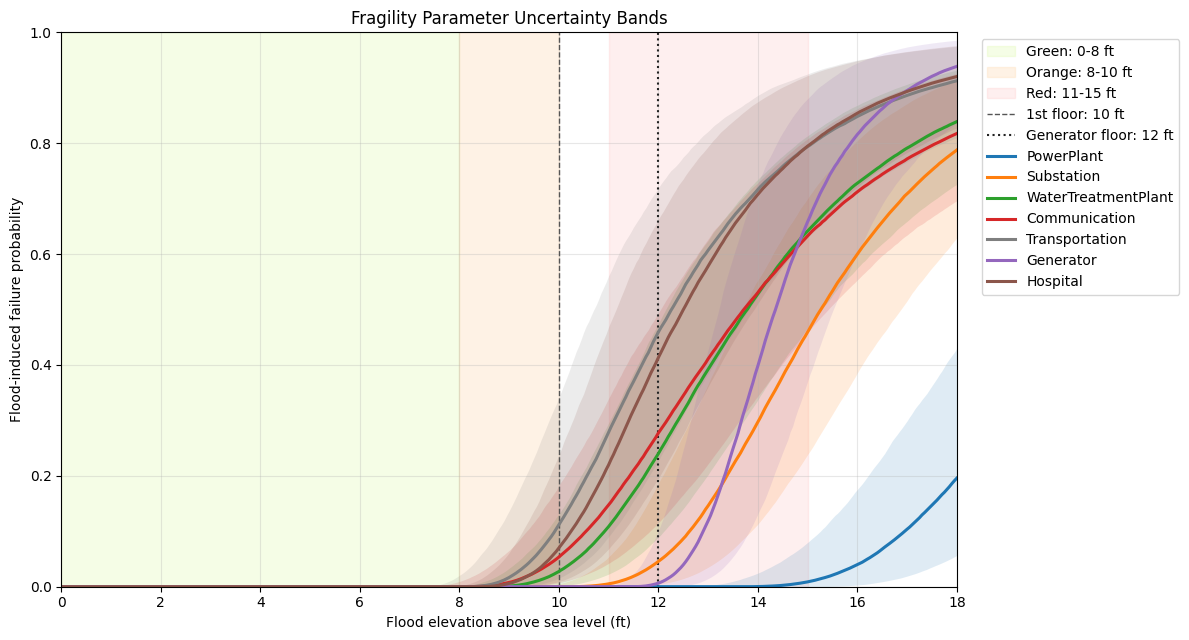

In [15]:
category_order = [
    "PowerPlant",
    "Substation",
    "WaterTreatmentPlant",
    "Communication",
    "Transportation",
    "Generator",
    "Hospital",
]

category_colors = {
    "PowerPlant": "#1f77b4",
    "Substation": "#ff7f0e",
    "WaterTreatmentPlant": "#2ca02c",
    "Communication": "#d62728",
    "Transportation": "#7f7f7f",
    "Generator": "#9467bd",
    "Hospital": "#8c564b",
}

plt.figure(figsize=(12, 6.5))

plt.axvspan(0, 8, color="#d9f99d", alpha=0.25, label="Green: 0-8 ft")
plt.axvspan(8, 10, color="#fed7aa", alpha=0.30, label="Orange: 8-10 ft")
plt.axvspan(11, 15, color="#fecaca", alpha=0.30, label="Red: 11-15 ft")
plt.axvline(10, color="#555555", linestyle="--", linewidth=1, label="1st floor: 10 ft")
plt.axvline(12, color="#222222", linestyle=":", linewidth=1.5, label="Generator floor: 12 ft")

for category in category_order:
    df_category = (
        fragility_uncertainty_summary[
            fragility_uncertainty_summary["node_category"] == category
        ]
        .sort_values("flood_elevation_ft")
    )

    x = df_category["flood_elevation_ft"].to_numpy()
    p05 = df_category["p05"].to_numpy()
    p50 = df_category["p50"].to_numpy()
    p95 = df_category["p95"].to_numpy()

    plt.fill_between(
        x,
        p05,
        p95,
        color=category_colors[category],
        alpha=0.14,
        linewidth=0,
    )
    plt.plot(
        x,
        p50,
        color=category_colors[category],
        linewidth=2.2,
        label=category,
    )

plt.xlabel("Flood elevation above sea level (ft)")
plt.ylabel("Flood-induced failure probability")
plt.title("Fragility Parameter Uncertainty Bands")
plt.ylim(0, 1)
plt.xlim(0, 18)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Dependency relationships

In [16]:
# ---------------------------------------------------------------------
# Dependency relationship settings
# ---------------------------------------------------------------------
# This cell does not add or modify routine probability rows.
# Missing routine probabilities are handled by your existing p_routine function.

GENERATOR_RUNTIME_DAYS = 6.3
q_buffered = 0.0  # generator works before expiration
q_expired = 1.0   # generator expires after 6.3 days

dependency_model = {
    # Sequential power chain
    "SUB_1_failed": {"type": "deterministic_or", "parents": ["PP_1_failed"]},
    "SUB_2_failed": {"type": "deterministic_or", "parents": ["SUB_1_failed"]},
    "SUB_3_failed": {"type": "deterministic_or", "parents": ["SUB_2_failed"]},
    "SUB_4_failed": {"type": "deterministic_or", "parents": ["SUB_3_failed"]},
    "SUB_5_failed": {"type": "deterministic_or", "parents": ["SUB_4_failed"]},

    # Activation node
    "Generator_activated": {
        "type": "activation",
        "parents": ["SUB_5_failed"],
    },

    # Electrical failure due to generator expiration
    "ElectricalDistribution_failed": {
        "type": "generator_runtime",
        "parents": ["Generator_activated"],
        "runtime_days": GENERATOR_RUNTIME_DAYS,
        "q_buffered": q_buffered,
        "q_expired": q_expired,
    },

    # Water dependency
    "WaterDistribution_failed": {
        "type": "noisy_or",
        "parents": ["WTP_1_failed", "ElectricalDistribution_failed"],
        "strengths": [1.00, 0.50],
    },

    # Communication redundancy
    "Communication_Tier1_failed": {
        "type": "redundant_all_failed",
        "parents": ["LEE_DARK_FIBER_failed", "LUMEN_MPLS_failed", "COMCAST_ENS_failed"],
    },
    "Communication_Tier2_failed": {
        "type": "redundant_all_failed",
        "parents": ["LUMEN_MPLS_failed", "COMCAST_ENS_failed"],
    },
    "Communication_Tier3_failed": {
        "type": "redundant_all_failed",
        "parents": ["LUMEN_MPLS_failed", "COMCAST_BUSINESS_failed", "TMOBILE_5G_failed"],
    },

    # Transportation / operations
    "Operations_capability_reduced": {
        "type": "deterministic_or",
        "parents": ["roads_bridges_closure"],
    },

    # Hospital tier dependencies
    "Tier1_failed": {
        "type": "noisy_or",
        "parents": [
            "ElectricalDistribution_failed",
            "WaterDistribution_failed",
            "Communication_Tier1_failed",
            "Operations_capability_reduced",
        ],
        "strengths": [0.95, 0.85, 0.70, 0.60],
    },
    "Tier2_failed": {
        "type": "noisy_or",
        "parents": [
            "ElectricalDistribution_failed",
            "WaterDistribution_failed",
            "Communication_Tier2_failed",
            "Operations_capability_reduced",
        ],
        "strengths": [0.90, 0.80, 0.65, 0.55],
    },
    "Tier3_failed": {
        "type": "noisy_or",
        "parents": [
            "ElectricalDistribution_failed",
            "WaterDistribution_failed",
            "Communication_Tier3_failed",
            "Operations_capability_reduced",
        ],
        "strengths": [0.85, 0.75, 0.60, 0.50],
    },
}


def noisy_or_from_states(parent_states, strengths):
    active_strengths = [
        strength
        for parent_state, strength in zip(parent_states, strengths)
        if parent_state == 1
    ]
    if not active_strengths:
        return 0.0
    return combine_independent_probabilities(*active_strengths)


def parent_caused_failure_probability(child, current_states, event_elapsed_days):
    spec = dependency_model.get(child)

    if spec is None:
        return 0.0

    parent_states = [current_states[parent] for parent in spec["parents"]]

    if spec["type"] == "activation":
        return 1.0 if parent_states[0] == 1 else 0.0

    if spec["type"] == "deterministic_or":
        return 1.0 if any(parent_states) else 0.0

    if spec["type"] == "redundant_all_failed":
        return 1.0 if all(parent_states) else 0.0

    if spec["type"] == "noisy_or":
        return noisy_or_from_states(parent_states, spec["strengths"])

    if spec["type"] == "generator_runtime":
        if parent_states[0] == 0:
            return 0.0

        if event_elapsed_days <= spec["runtime_days"]:
            return spec["q_buffered"]

        return spec["q_expired"]

    raise ValueError(f"Unknown dependency type for {child}: {spec['type']}")

## Temporal persistence (TBC)

In [17]:
# ---------------------------------------------------------------------
# Temporal persistence and recovery settings
# ---------------------------------------------------------------------
# Temporal persistence only applies to physical/external infrastructure
# nodes whose failed state can reasonably persist across timestamps.
#
# Temporal logic:
# - failed at t-1 -> recovered/functional at t with probability recovery_p
# - failed at t-1 -> remains failed at t with probability 1 - recovery_p
# - functional at t-1 -> failed at t is NOT caused by temporal persistence;
#   new failures only come from routine, direct flood, or parent dependencies.
#
# Functional/service aggregation nodes are recalculated at each timestamp:
# - Generator_activated
# - WaterDistribution_failed
# - Communication_Tier*_failed
# - Operations_capability_reduced
# - Tier*_failed
# ---------------------------------------------------------------------

RECOVERY_TREND_EPSILON_FT = 0.05

TEMPORAL_PERSISTENCE_NODES = {
    "PP_1_failed",
    "SUB_1_failed",
    "SUB_2_failed",
    "SUB_3_failed",
    "SUB_4_failed",
    "SUB_5_failed",

    "WTP_1_failed",

    "LEE_DARK_FIBER_failed",
    "LUMEN_MPLS_failed",
    "COMCAST_ENS_failed",
    "COMCAST_BUSINESS_failed",
    "TMOBILE_5G_failed",

    "roads_bridges_closure",

    "ElectricalDistribution_failed",
}

recovery_parameter_table = pd.DataFrame([
    {
        "node_category": "PowerPlant",
        "mean_recovery_hours_accessible": 48,
        "h_caution_ft": 14,
        "h_blocked_ft": 17,
    },
    {
        "node_category": "Substation",
        "mean_recovery_hours_accessible": 24,
        "h_caution_ft": 10,
        "h_blocked_ft": 13,
    },
    {
        "node_category": "WaterTreatmentPlant",
        "mean_recovery_hours_accessible": 48,
        "h_caution_ft": 14,
        "h_blocked_ft": 17,
    },
    {
        "node_category": "Communication",
        "mean_recovery_hours_accessible": 12,
        "h_caution_ft": 8,
        "h_blocked_ft": 12,
    },
    {
        "node_category": "Transportation",
        "mean_recovery_hours_accessible": 24,
        "h_caution_ft": 9,
        "h_blocked_ft": 12,
    },
    {
        "node_category": "Generator",
        "mean_recovery_hours_accessible": 12,
        "h_caution_ft": 12,
        "h_blocked_ft": 15,
    },
])

recovery_parameter_table["base_recovery_p_per_hour"] = (
    1.0 - np.exp(-1.0 / recovery_parameter_table["mean_recovery_hours_accessible"])
)


def recovery_access_factor(flood_elevation_ft, h_caution_ft, h_blocked_ft):
    """
    Recovery is slower when flood elevation is high because access,
    inspection, repair, and replacement are constrained.
    """
    if flood_elevation_ft >= h_blocked_ft:
        return 0.05

    if flood_elevation_ft >= h_caution_ft:
        return 0.25

    return 1.00


def recovery_trend_factor(current_flood_ft, previous_flood_ft, epsilon_ft=RECOVERY_TREND_EPSILON_FT):
    """
    Recovery is slowest while water is rising, partial while water is stable,
    and fastest while water is receding.
    """
    if previous_flood_ft is None:
        return 1.00

    delta_ft = current_flood_ft - previous_flood_ft

    if delta_ft > epsilon_ft:
        return 0.25

    if abs(delta_ft) <= epsilon_ft:
        return 0.60

    return 1.00


def recovery_probability(variable, current_flood_ft, previous_flood_ft=None):
    """
    Hourly recovery probability for persistent physical/external nodes.
    Returns 0 for non-persistent functional/service aggregation nodes.
    """
    if variable not in TEMPORAL_PERSISTENCE_NODES:
        return 0.0

    if variable not in node_category_lookup:
        return 0.0

    node_category = node_category_lookup[variable]

    params = recovery_parameter_table[
        recovery_parameter_table["node_category"] == node_category
    ]

    if params.empty:
        return 0.0

    row = params.iloc[0]

    base_recovery_p = row["base_recovery_p_per_hour"]
    access_factor = recovery_access_factor(
        flood_elevation_ft=current_flood_ft,
        h_caution_ft=row["h_caution_ft"],
        h_blocked_ft=row["h_blocked_ft"],
    )
    trend_factor = recovery_trend_factor(
        current_flood_ft=current_flood_ft,
        previous_flood_ft=previous_flood_ft,
    )

    return float(base_recovery_p * access_factor * trend_factor)


def sample_persistence_transition(variable, previous_state, current_flood_ft, previous_flood_ft, rng):
    """
    Sample whether a previous failed state persists into the current timestamp.

    This function only models failed -> functional recovery. New failures are sampled separately from
    routine, direct flood, and parent dependencies.
    """
    if previous_state == 0:
        return {
            "persisted_failed": 0,
            "recovered": 0,
            "recovery_p": 0.0,
        }

    if variable not in TEMPORAL_PERSISTENCE_NODES:
        return {
            "persisted_failed": 0,
            "recovered": 0,
            "recovery_p": 0.0,
        }

    recovery_p = recovery_probability(
        variable=variable,
        current_flood_ft=current_flood_ft,
        previous_flood_ft=previous_flood_ft,
    )

    recovered = int(rng.random() < recovery_p)
    persisted_failed = int(recovered == 0)

    return {
        "persisted_failed": persisted_failed,
        "recovered": recovered,
        "recovery_p": recovery_p,
    }


def sample_temporal_persistence(previous_state, recovery_p, rng):
    """
    Backward-compatible helper for simple one-node examples.
    The DBN inference uses sample_persistence_transition instead.
    """
    if previous_state == 0:
        return 0

    return int(rng.random() >= recovery_p)


recovery_parameter_table


,node_category,mean_recovery_hours_accessible,h_caution_ft,h_blocked_ft,base_recovery_p_per_hour
0,PowerPlant,48,14,17,0.020618
1,Substation,24,10,13,0.040811
2,WaterTreatmentPlant,48,14,17,0.020618
3,Communication,12,8,12,0.079956
4,Transportation,24,9,12,0.040811
5,Generator,12,12,15,0.079956


# Flood depth mapping

In [18]:
# ---------------------------------------------------------------------
# Read full USGS file and aggregate 15-min data to hourly maximum
# ---------------------------------------------------------------------

file_path = r"../../Data/Ian/FL - USGS-02291673.xls"
df_usgs = pd.read_excel(file_path)

df_usgs["time"] = pd.to_datetime(df_usgs["time"], utc=True)
df_usgs["time_local"] = df_usgs["time"].dt.tz_convert("America/New_York")

df_usgs = df_usgs.sort_values("time_local").reset_index(drop=True)

df_flood_hourly = (
    df_usgs
    .set_index("time_local")
    .resample("1h")
    .max(numeric_only=True)
    .dropna(subset=["value_meter"])
    .reset_index()
)

df_flood_hourly["time_step"] = np.arange(len(df_flood_hourly))
df_flood_hourly["event_elapsed_hours"] = (
    df_flood_hourly["time_local"] - df_flood_hourly["time_local"].iloc[0]
).dt.total_seconds() / 3600.0
df_flood_hourly["event_elapsed_days"] = df_flood_hourly["event_elapsed_hours"] / 24.0

df_flood_hourly["water_elevation_m"] = df_flood_hourly["value_meter"]
df_flood_hourly["water_elevation_ft"] = df_flood_hourly["water_elevation_m"] / FT_TO_M

DBN_HAZARD_COL = "water_elevation_ft"

display(df_flood_hourly)

print("Hourly rows:", len(df_flood_hourly))
print("Start:", df_flood_hourly["time_local"].iloc[0])
print("End:", df_flood_hourly["time_local"].iloc[-1])
print("Peak ft:", df_flood_hourly["water_elevation_ft"].max())

,time_local,x,y,parameter_code,statistic_id,value,value_meter,qualifier,time_step,event_elapsed_hours,event_elapsed_days,water_elevation_m,water_elevation_ft
0,2022-09-24 00:00:00-04:00,NaN,NaN,65,11,6.22,1.895856,NaN,0,0.0,0.000000,1.895856,6.22
1,2022-09-24 01:00:00-04:00,NaN,NaN,65,11,6.22,1.895856,NaN,1,1.0,0.041667,1.895856,6.22
2,2022-09-24 02:00:00-04:00,NaN,NaN,65,11,6.22,1.895856,NaN,2,2.0,0.083333,1.895856,6.22
3,2022-09-24 03:00:00-04:00,NaN,NaN,65,11,6.22,1.895856,NaN,3,3.0,0.125000,1.895856,6.22
4,2022-09-24 04:00:00-04:00,NaN,NaN,65,11,6.21,1.892808,NaN,4,4.0,0.166667,1.892808,6.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,2022-10-08 19:00:00-04:00,NaN,NaN,65,11,6.33,1.929384,NaN,355,355.0,14.791667,1.929384,6.33
356,2022-10-08 20:00:00-04:00,NaN,NaN,65,11,6.32,1.926336,NaN,356,356.0,14.833333,1.926336,6.32
357,2022-10-08 21:00:00-04:00,NaN,NaN,65,11,6.32,1.926336,NaN,357,357.0,14.875000,1.926336,6.32
358,2022-10-08 22:00:00-04:00,NaN,NaN,65,11,6.32,1.926336,NaN,358,358.0,14.916667,1.926336,6.32


Hourly rows: 360
Start: 2022-09-24 00:00:00-04:00
End: 2022-10-08 23:00:00-04:00
Peak ft: 10.659999658880011


In [19]:
df_flood_hourly["water_elevation_ft"].describe().round(2)

count    360.00
mean       6.72
std        0.78
min        5.96
25%        6.22
50%        6.56
75%        6.86
max       10.66
Name: water_elevation_ft, dtype: float64

In [20]:
# ---------------------------------------------------------------------
# 4. Build depth series for every node at every timestamp
# ---------------------------------------------------------------------

G_hosp = nx.DiGraph()
G_hosp.add_edges_from(
    dependency_edges[["parent", "child"]].itertuples(index=False, name=None)
)

if not nx.is_directed_acyclic_graph(G_hosp):
    raise ValueError("The established dependency network contains a cycle.")

dbn_node_order = list(nx.topological_sort(G_hosp))

def build_depth_series_same_for_all_nodes(G, df_flood, depth_col=DBN_HAZARD_COL):
    depths_series = []

    for _, row in df_flood.iterrows():
        depths_series.append({
            "time_step": int(row["time_step"]),
            "time_local": row["time_local"],
            "event_elapsed_hours": float(row["event_elapsed_hours"]),
            "event_elapsed_days": float(row["event_elapsed_days"]),
            "depth_by_node": {
                node: float(row[depth_col])
                for node in G.nodes()
            },
        })

    return depths_series

depths_series = build_depth_series_same_for_all_nodes(
    G_hosp,
    df_flood_hourly,
    depth_col=DBN_HAZARD_COL,
)

print("Number of DBN hourly timestamps:", len(depths_series))
print("Example first timestamp:", depths_series[0])

Number of DBN hourly timestamps: 360
Example first timestamp: {'time_step': 0, 'time_local': Timestamp('2022-09-24 00:00:00-0400', tz='America/New_York'), 'event_elapsed_hours': 0.0, 'event_elapsed_days': 0.0, 'depth_by_node': {'PP_1_failed': 6.219999800960006, 'SUB_1_failed': 6.219999800960006, 'SUB_2_failed': 6.219999800960006, 'SUB_3_failed': 6.219999800960006, 'SUB_4_failed': 6.219999800960006, 'SUB_5_failed': 6.219999800960006, 'Generator_activated': 6.219999800960006, 'ElectricalDistribution_failed': 6.219999800960006, 'WTP_1_failed': 6.219999800960006, 'WaterDistribution_failed': 6.219999800960006, 'LEE_DARK_FIBER_failed': 6.219999800960006, 'Communication_Tier1_failed': 6.219999800960006, 'LUMEN_MPLS_failed': 6.219999800960006, 'COMCAST_ENS_failed': 6.219999800960006, 'Communication_Tier2_failed': 6.219999800960006, 'Communication_Tier3_failed': 6.219999800960006, 'COMCAST_BUSINESS_failed': 6.219999800960006, 'TMOBILE_5G_failed': 6.219999800960006, 'roads_bridges_closure': 6.21

# DBN inference

In [21]:
# ---------------------------------------------------------------------
# DBN inference setup checks
# ---------------------------------------------------------------------

if not nx.is_directed_acyclic_graph(G_hosp):
    raise ValueError("G_hosp must be a directed acyclic graph for within-slice DBN sampling.")

dbn_node_order = list(nx.topological_sort(G_hosp))

missing_dependency_specs = [
    node for node in dbn_node_order
    if G_hosp.in_degree(node) > 0 and node not in dependency_model
]
if missing_dependency_specs:
    raise ValueError(f"Missing dependency_model specs for: {missing_dependency_specs}")

missing_recovery_functions = [
    name for name in [
        "recovery_access_factor",
        "recovery_trend_factor",
        "recovery_probability",
        "sample_persistence_transition",
    ]
    if name not in globals()
]
if missing_recovery_functions:
    raise NameError(f"Missing temporal recovery functions: {missing_recovery_functions}")

print("DBN nodes:", len(dbn_node_order))
print("DBN time steps:", len(depths_series))
print("Recovery categories:", recovery_parameter_table["node_category"].tolist())


DBN nodes: 23
DBN time steps: 360
Recovery categories: ['PowerPlant', 'Substation', 'WaterTreatmentPlant', 'Communication', 'Transportation', 'Generator']


In [22]:
# ---------------------------------------------------------------------
# DBN Monte Carlo helper functions
# ---------------------------------------------------------------------

def direct_flood_probability(variable, flood_elevation_ft):
    if variable == "Generator_activated":
        return 0.0

    if variable not in node_category_lookup:
        return 0.0

    return p_flood_failure_by_category(
        node_category_lookup[variable],
        flood_elevation_ft,
    )


def sample_independent_event(probability, rng):
    probability = min(max(float(probability), 0.0), 1.0)
    return int(rng.random() < probability)


def sample_parent_cause_events(child, current_states, generator_elapsed_days, rng):
    """
    Returns sampled parent-caused events for the child node.

    Generator runtime is evaluated using elapsed time since SUB_5_failed first
    triggered Generator_activated within the current Monte Carlo particle.
    """
    spec = dependency_model.get(child)

    if spec is None:
        return {}

    parent_states = {
        parent: current_states[parent]
        for parent in spec["parents"]
    }

    if spec["type"] == "activation":
        parent = spec["parents"][0]
        return {parent: int(parent_states[parent] == 1)}

    if spec["type"] == "deterministic_or":
        return {
            parent: int(state == 1)
            for parent, state in parent_states.items()
        }

    if spec["type"] == "redundant_all_failed":
        return {
            "redundant_provider_failures": int(
                all(state == 1 for state in parent_states.values())
            )
        }

    if spec["type"] == "noisy_or":
        events = {}

        for parent, strength in zip(spec["parents"], spec["strengths"]):
            if parent_states[parent] == 1:
                events[parent] = sample_independent_event(strength, rng)
            else:
                events[parent] = 0

        return events

    if spec["type"] == "generator_runtime":
        parent = spec["parents"][0]

        if parent_states[parent] == 0:
            return {"generator_runtime_expired": 0}

        if generator_elapsed_days is None:
            return {"generator_runtime_expired": 0}

        if generator_elapsed_days <= spec["runtime_days"]:
            q_generator_failure = spec["q_buffered"]
        else:
            q_generator_failure = spec["q_expired"]

        return {
            "generator_runtime_expired": sample_independent_event(
                q_generator_failure,
                rng,
            )
        }

    raise ValueError(f"Unknown dependency type for {child}: {spec['type']}")


def sample_node_state_with_recovery(
    node,
    previous_state,
    routine_p,
    flood_p,
    parent_events,
    current_flood_ft,
    previous_flood_ft,
    rng,
):
    persistence = sample_persistence_transition(
        variable=node,
        previous_state=previous_state,
        current_flood_ft=current_flood_ft,
        previous_flood_ft=previous_flood_ft,
        rng=rng,
    )

    routine_event = sample_independent_event(routine_p, rng)
    flood_event = sample_independent_event(flood_p, rng)
    parent_event = int(any(parent_events.values()))

    new_failure_event = int(
        routine_event == 1
        or flood_event == 1
        or parent_event == 1
    )

    state = int(
        persistence["persisted_failed"] == 1
        or new_failure_event == 1
    )

    return {
        "state": state,
        "persisted_failed": persistence["persisted_failed"],
        "recovered": persistence["recovered"],
        "recovery_p": persistence["recovery_p"],
        "routine_event": routine_event,
        "flood_event": flood_event,
        "parent_event": parent_event,
        "new_failure_event": new_failure_event,
    }


def allocate_failure_cause_shares(active_causes):
    active_causes = [
        cause for cause, active in active_causes.items()
        if active == 1
    ]

    if not active_causes:
        return {}

    share = 1.0 / len(active_causes)
    return {cause: share for cause in active_causes}


In [23]:
# ---------------------------------------------------------------------
# DBN Monte Carlo simulation
# ---------------------------------------------------------------------
# Generator runtime clock:
# - Starts when SUB_5_failed first becomes 1 in a Monte Carlo particle.
# - Continues while SUB_5_failed remains 1.
# - Resets when SUB_5_failed returns to 0.
#
# Temporal recovery logic:
# - Persistence only models failed -> functional recovery.
# - Functional -> failed transitions are caused only by routine, flood, or parents.


def run_dbn_monte_carlo(depths_series, n_samples=1000, seed=42, progress_every=100):
    rng = np.random.default_rng(seed)

    state_records = []
    cause_records = []

    tier_nodes = ["Tier1_failed", "Tier2_failed", "Tier3_failed"]

    for sample_id in range(n_samples):
        previous_states = {node: 0 for node in dbn_node_order}
        previous_depth_by_node = None

        generator_activation_start_hour = None
        generator_elapsed_days = None

        if progress_every and sample_id % progress_every == 0:
            print(f"Running DBN Monte Carlo sample {sample_id} of {n_samples}...")

        for step in depths_series:
            time_step = step["time_step"]
            time_local = step["time_local"]
            event_elapsed_hours = step["event_elapsed_hours"]
            event_elapsed_days = step["event_elapsed_days"]
            depth_by_node = step["depth_by_node"]

            current_states = {}

            for node in dbn_node_order:
                current_flood_ft = depth_by_node[node]

                previous_flood_ft = None
                if previous_depth_by_node is not None:
                    previous_flood_ft = previous_depth_by_node[node]

                if node == "Generator_activated":
                    sub5_failed = current_states["SUB_5_failed"]

                    if sub5_failed == 1:
                        if generator_activation_start_hour is None:
                            generator_activation_start_hour = event_elapsed_hours

                        generator_elapsed_days = (
                            event_elapsed_hours - generator_activation_start_hour
                        ) / 24.0

                        state = 1
                        parent_events = {"SUB_5_failed": 1}
                    else:
                        generator_activation_start_hour = None
                        generator_elapsed_days = None

                        state = 0
                        parent_events = {"SUB_5_failed": 0}

                    transition = {
                        "persisted_failed": 0,
                        "recovered": 0,
                        "recovery_p": 0.0,
                        "routine_event": 0,
                        "flood_event": 0,
                        "parent_event": int(any(parent_events.values())),
                        "new_failure_event": int(any(parent_events.values())),
                    }

                else:
                    parent_events = sample_parent_cause_events(
                        child=node,
                        current_states=current_states,
                        generator_elapsed_days=generator_elapsed_days,
                        rng=rng,
                    )

                    transition = sample_node_state_with_recovery(
                        node=node,
                        previous_state=previous_states[node],
                        routine_p=p_routine(node),
                        flood_p=direct_flood_probability(node, current_flood_ft),
                        parent_events=parent_events,
                        current_flood_ft=current_flood_ft,
                        previous_flood_ft=previous_flood_ft,
                        rng=rng,
                    )

                    state = transition["state"]

                current_states[node] = state

                state_records.append({
                    "sample_id": sample_id,
                    "time_step": time_step,
                    "time_local": time_local,
                    "event_elapsed_hours": event_elapsed_hours,
                    "event_elapsed_days": event_elapsed_days,
                    "variable": node,
                    "flood_elevation_ft": current_flood_ft,
                    "state": state,
                    "persisted_failed": transition["persisted_failed"],
                    "recovered": transition["recovered"],
                    "recovery_p": transition["recovery_p"],
                    "routine_event": transition["routine_event"],
                    "flood_event": transition["flood_event"],
                    "parent_event": transition["parent_event"],
                    "new_failure_event": transition["new_failure_event"],
                    "generator_elapsed_days": generator_elapsed_days,
                })

                if node in tier_nodes and state == 1:
                    # Temporal persistence is intentionally excluded from cause attribution.
                    # It is a memory/recovery mechanism, not an initiating failure cause.
                    active_causes = {
                        "routine": transition["routine_event"],
                        "direct_flood": transition["flood_event"],
                    }

                    for cause, active in parent_events.items():
                        if cause == "ElectricalDistribution_failed":
                            active_causes["electrical_distribution"] = active
                        elif cause == "WaterDistribution_failed":
                            active_causes["water_distribution"] = active
                        elif cause.startswith("Communication_Tier"):
                            active_causes["communication"] = active
                        elif cause == "Operations_capability_reduced":
                            active_causes["operations_transportation"] = active
                        elif cause == "generator_runtime_expired":
                            active_causes["generator_runtime_expired"] = active
                        else:
                            active_causes[cause] = active

                    cause_shares = allocate_failure_cause_shares(active_causes)

                    for cause, share in cause_shares.items():
                        cause_records.append({
                            "sample_id": sample_id,
                            "time_step": time_step,
                            "time_local": time_local,
                            "event_elapsed_hours": event_elapsed_hours,
                            "event_elapsed_days": event_elapsed_days,
                            "tier": node,
                            "cause": cause,
                            "cause_share": share,
                        })

            previous_states = current_states
            previous_depth_by_node = depth_by_node

    dbn_state_samples = pd.DataFrame(state_records)
    dbn_tier_cause_samples = pd.DataFrame(cause_records)

    return dbn_state_samples, dbn_tier_cause_samples


# Increase n_samples for final results after checking runtime and behavior.
dbn_state_samples, dbn_tier_cause_samples = run_dbn_monte_carlo(
    depths_series=depths_series,
    n_samples=1000,
    seed=42,
)

display(dbn_state_samples.head())
display(dbn_tier_cause_samples.head())


Running DBN Monte Carlo sample 0 of 1000...
Running DBN Monte Carlo sample 100 of 1000...
Running DBN Monte Carlo sample 200 of 1000...
Running DBN Monte Carlo sample 300 of 1000...
Running DBN Monte Carlo sample 400 of 1000...
Running DBN Monte Carlo sample 500 of 1000...
Running DBN Monte Carlo sample 600 of 1000...
Running DBN Monte Carlo sample 700 of 1000...
Running DBN Monte Carlo sample 800 of 1000...
Running DBN Monte Carlo sample 900 of 1000...


,sample_id,time_step,time_local,event_elapsed_hours,event_elapsed_days,variable,flood_elevation_ft,state,persisted_failed,recovered,recovery_p,routine_event,flood_event,parent_event,new_failure_event,generator_elapsed_days
0,0,0,2022-09-24 00:00:00-04:00,0.0,0.0,PP_1_failed,6.22,0,0,0,0.0,0,0,0,0,NaN
1,0,0,2022-09-24 00:00:00-04:00,0.0,0.0,WTP_1_failed,6.22,0,0,0,0.0,0,0,0,0,NaN
2,0,0,2022-09-24 00:00:00-04:00,0.0,0.0,LEE_DARK_FIBER_failed,6.22,0,0,0,0.0,0,0,0,0,NaN
3,0,0,2022-09-24 00:00:00-04:00,0.0,0.0,LUMEN_MPLS_failed,6.22,0,0,0,0.0,0,0,0,0,NaN
4,0,0,2022-09-24 00:00:00-04:00,0.0,0.0,COMCAST_ENS_failed,6.22,0,0,0,0.0,0,0,0,0,NaN


,sample_id,time_step,time_local,event_elapsed_hours,event_elapsed_days,tier,cause,cause_share
0,0,113,2022-09-28 17:00:00-04:00,113.0,4.708333,Tier1_failed,direct_flood,0.5
1,0,113,2022-09-28 17:00:00-04:00,113.0,4.708333,Tier1_failed,operations_transportation,0.5
2,0,114,2022-09-28 18:00:00-04:00,114.0,4.750000,Tier1_failed,direct_flood,1.0
3,0,114,2022-09-28 18:00:00-04:00,114.0,4.750000,Tier2_failed,direct_flood,0.5
4,0,114,2022-09-28 18:00:00-04:00,114.0,4.750000,Tier2_failed,operations_transportation,0.5


In [24]:
# ---------------------------------------------------------------------
# Summarize DBN failure probabilities
# ---------------------------------------------------------------------

dbn_probability_summary = (
    dbn_state_samples
    .groupby(
        [
            "time_step",
            "time_local",
            "event_elapsed_hours",
            "event_elapsed_days",
            "variable",
        ],
        as_index=False,
    )
    .agg(
        p_failed_or_activated=("state", "mean"),
        flood_elevation_ft=("flood_elevation_ft", "mean"),
    )
)

dbn_probability_wide = dbn_probability_summary.pivot(
    index=[
        "time_step",
        "time_local",
        "event_elapsed_hours",
        "event_elapsed_days",
        "flood_elevation_ft",
    ],
    columns="variable",
    values="p_failed_or_activated",
).reset_index()

tier_probability_summary = dbn_probability_summary[
    dbn_probability_summary["variable"].isin(
        ["Tier1_failed", "Tier2_failed", "Tier3_failed"]
    )
].copy()

display(dbn_probability_summary.head())
display(dbn_probability_wide.head())
display(tier_probability_summary.head())


,time_step,time_local,event_elapsed_hours,event_elapsed_days,variable,p_failed_or_activated,flood_elevation_ft
0,0,2022-09-24 00:00:00-04:00,0.0,0.0,COMCAST_BUSINESS_failed,0.0,6.22
1,0,2022-09-24 00:00:00-04:00,0.0,0.0,COMCAST_ENS_failed,0.0,6.22
2,0,2022-09-24 00:00:00-04:00,0.0,0.0,Communication_Tier1_failed,0.0,6.22
3,0,2022-09-24 00:00:00-04:00,0.0,0.0,Communication_Tier2_failed,0.0,6.22
4,0,2022-09-24 00:00:00-04:00,0.0,0.0,Communication_Tier3_failed,0.0,6.22


variable,time_step,time_local,event_elapsed_hours,event_elapsed_days,flood_elevation_ft,COMCAST_BUSINESS_failed,COMCAST_ENS_failed,Communication_Tier1_failed,Communication_Tier2_failed,Communication_Tier3_failed,ElectricalDistribution_failed,Generator_activated,LEE_DARK_FIBER_failed,LUMEN_MPLS_failed,Operations_capability_reduced,PP_1_failed,SUB_1_failed,SUB_2_failed,SUB_3_failed,SUB_4_failed,SUB_5_failed,TMOBILE_5G_failed,Tier1_failed,Tier2_failed,Tier3_failed,WTP_1_failed,WaterDistribution_failed,roads_bridges_closure
0,0,2022-09-24 00:00:00-04:00,0.0,0.000000,6.22,0.000,0.000,0.0,0.0,0.0,0.0,0.002,0.000,0.002,0.0,0.0,0.0,0.000,0.000,0.002,0.002,0.000,0.000,0.000,0.000,0.000,0.000,0.0
1,1,2022-09-24 01:00:00-04:00,1.0,0.041667,6.22,0.000,0.001,0.0,0.0,0.0,0.0,0.007,0.002,0.001,0.0,0.0,0.0,0.002,0.003,0.006,0.007,0.000,0.000,0.002,0.002,0.002,0.002,0.0
2,2,2022-09-24 02:00:00-04:00,2.0,0.083333,6.22,0.000,0.003,0.0,0.0,0.0,0.0,0.010,0.003,0.002,0.0,0.0,0.0,0.003,0.005,0.009,0.010,0.000,0.002,0.002,0.000,0.002,0.002,0.0
3,3,2022-09-24 03:00:00-04:00,3.0,0.125000,6.22,0.000,0.004,0.0,0.0,0.0,0.0,0.012,0.003,0.003,0.0,0.0,0.0,0.004,0.006,0.011,0.012,0.003,0.003,0.002,0.003,0.003,0.003,0.0
4,4,2022-09-24 04:00:00-04:00,4.0,0.166667,6.21,0.001,0.005,0.0,0.0,0.0,0.0,0.013,0.004,0.003,0.0,0.0,0.0,0.004,0.006,0.012,0.013,0.002,0.004,0.004,0.002,0.004,0.004,0.0


,time_step,time_local,event_elapsed_hours,event_elapsed_days,variable,p_failed_or_activated,flood_elevation_ft
17,0,2022-09-24 00:00:00-04:00,0.0,0.000000,Tier1_failed,0.000,6.22
18,0,2022-09-24 00:00:00-04:00,0.0,0.000000,Tier2_failed,0.000,6.22
19,0,2022-09-24 00:00:00-04:00,0.0,0.000000,Tier3_failed,0.000,6.22
40,1,2022-09-24 01:00:00-04:00,1.0,0.041667,Tier1_failed,0.000,6.22
41,1,2022-09-24 01:00:00-04:00,1.0,0.041667,Tier2_failed,0.002,6.22


In [29]:
dbn_probability_wide.to_csv("../output/dbn_probability_wide.csv", index=False)

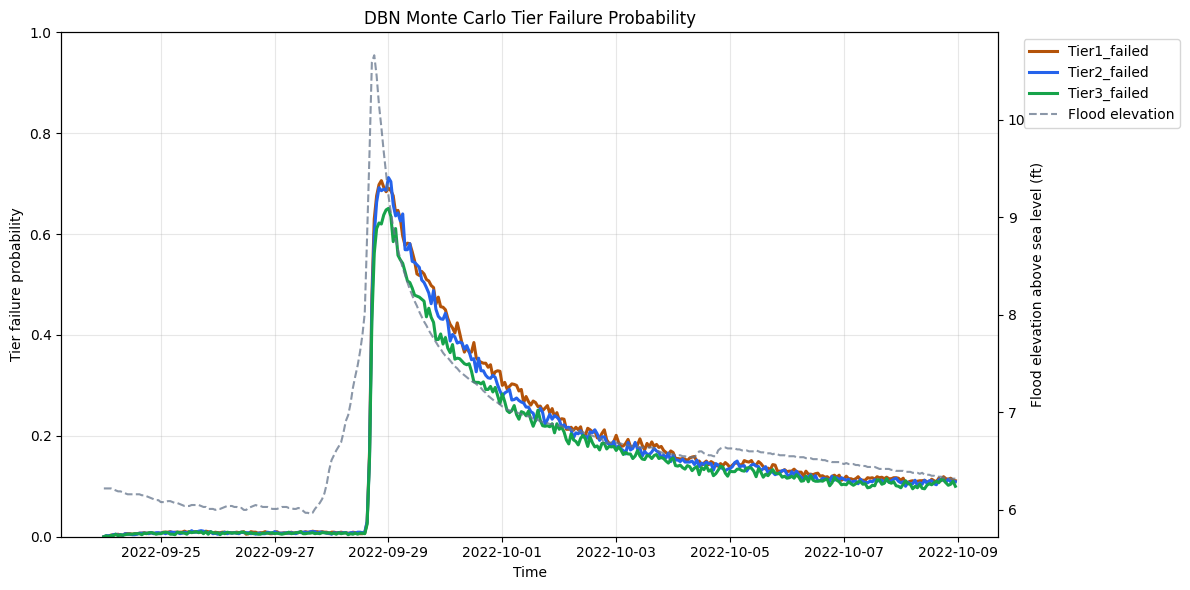

In [25]:
# ---------------------------------------------------------------------
# Plot Tier 1, Tier 2, and Tier 3 failure probabilities
# ---------------------------------------------------------------------

tier_plot_colors = {
    "Tier1_failed": "#b45309",
    "Tier2_failed": "#2563eb",
    "Tier3_failed": "#16a34a",
}

plt.figure(figsize=(12, 6))
ax1 = plt.gca()

for tier, color in tier_plot_colors.items():
    df_tier = tier_probability_summary[
        tier_probability_summary["variable"] == tier
    ].sort_values("time_local")

    ax1.plot(
        df_tier["time_local"],
        df_tier["p_failed_or_activated"],
        linewidth=2.2,
        color=color,
        label=tier,
    )

ax1.set_xlabel("Time")
ax1.set_ylabel("Tier failure probability")
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
flood_plot_df = dbn_probability_wide.sort_values("time_local")

ax2.plot(
    flood_plot_df["time_local"],
    flood_plot_df["flood_elevation_ft"],
    color="#64748b",
    linestyle="--",
    linewidth=1.5,
    alpha=0.75,
    label="Flood elevation",
)

ax2.set_ylabel("Flood elevation above sea level (ft)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.title("DBN Monte Carlo Tier Failure Probability")
plt.tight_layout()
plt.show()


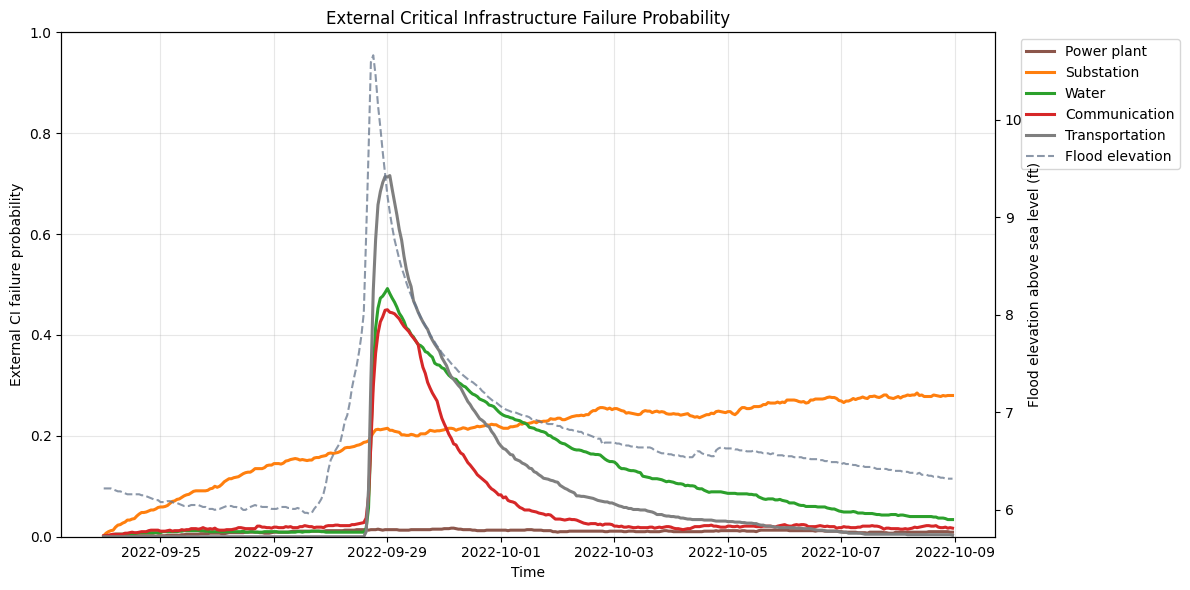

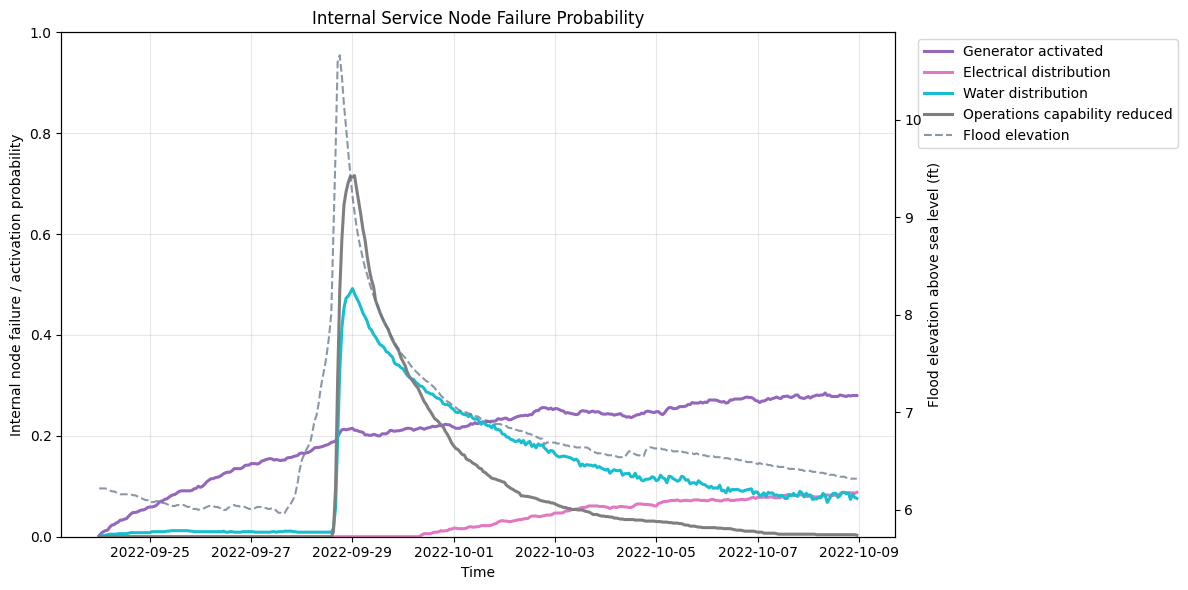

In [26]:
# ---------------------------------------------------------------------
# Plot external CI and internal service-node failure probabilities separately
# ---------------------------------------------------------------------


def plot_probability_timeseries(
    plot_df,
    label_col,
    value_col,
    color_map,
    ylabel,
    title,
):
    plt.figure(figsize=(12, 6))
    ax1 = plt.gca()

    for label, color in color_map.items():
        df_label = plot_df[plot_df[label_col] == label].sort_values("time_local")

        ax1.plot(
            df_label["time_local"],
            df_label[value_col],
            linewidth=2.2,
            color=color,
            label=label,
        )

    ax1.set_xlabel("Time")
    ax1.set_ylabel(ylabel)
    ax1.set_ylim(0, 1)
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    flood_plot_df = dbn_probability_wide.sort_values("time_local")

    ax2.plot(
        flood_plot_df["time_local"],
        flood_plot_df["flood_elevation_ft"],
        color="#64748b",
        linestyle="--",
        linewidth=1.5,
        alpha=0.75,
        label="Flood elevation",
    )
    ax2.set_ylabel("Flood elevation above sea level (ft)")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        lines1 + lines2,
        labels1 + labels2,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

    plt.title(title)
    plt.tight_layout()
    plt.show()


# External CI nodes/assets. Communication providers are grouped with max probability
# so the line represents the most stressed communication provider at each timestamp.
external_ci_group_map = {
    "PP_1_failed": "Power plant",
    "SUB_5_failed": "Substation",
    "WTP_1_failed": "Water",
    "roads_bridges_closure": "Transportation",
    "LEE_DARK_FIBER_failed": "Communication",
    "LUMEN_MPLS_failed": "Communication",
    "COMCAST_ENS_failed": "Communication",
    "COMCAST_BUSINESS_failed": "Communication",
    "TMOBILE_5G_failed": "Communication",
}

external_ci_summary = dbn_probability_summary[
    dbn_probability_summary["variable"].isin(external_ci_group_map)
].copy()
external_ci_summary["ci_group"] = external_ci_summary["variable"].map(external_ci_group_map)

external_ci_group_ts = (
    external_ci_summary
    .groupby(["time_step", "time_local", "event_elapsed_hours", "event_elapsed_days", "ci_group"], as_index=False)
    .agg(
        group_failure_probability=("p_failed_or_activated", "max"),
        flood_elevation_ft=("flood_elevation_ft", "mean"),
    )
)

external_ci_colors = {
    "Power plant": "#8c564b",
    "Substation": "#ff7f0e",
    "Water": "#2ca02c",
    "Communication": "#d62728",
    "Transportation": "#7f7f7f",
}

plot_probability_timeseries(
    plot_df=external_ci_group_ts,
    label_col="ci_group",
    value_col="group_failure_probability",
    color_map=external_ci_colors,
    ylabel="External CI failure probability",
    title="External Critical Infrastructure Failure Probability",
)


# Internal service/functional nodes inside the HealthPark dependency model.
internal_node_label_map = {
    "Generator_activated": "Generator activated",
    "ElectricalDistribution_failed": "Electrical distribution",
    "WaterDistribution_failed": "Water distribution",
    "Operations_capability_reduced": "Operations capability reduced",
}

internal_node_summary = dbn_probability_summary[
    dbn_probability_summary["variable"].isin(internal_node_label_map)
].copy()
internal_node_summary["internal_node"] = internal_node_summary["variable"].map(
    internal_node_label_map
)

internal_node_colors = {
    "Generator activated": "#9467bd",
    "Electrical distribution": "#e377c2",
    "Water distribution": "#17becf",
    "Operations capability reduced": "#7f7f7f",
}

plot_probability_timeseries(
    plot_df=internal_node_summary,
    label_col="internal_node",
    value_col="p_failed_or_activated",
    color_map=internal_node_colors,
    ylabel="Internal node failure / activation probability",
    title="Internal Service Node Failure Probability",
)


In [27]:
# ---------------------------------------------------------------------
# Summarize failure-cause composition for Tier 1, Tier 2, and Tier 3
# ---------------------------------------------------------------------

if dbn_tier_cause_samples.empty:
    tier_cause_time_summary = pd.DataFrame()
    tier_cause_overall_summary = pd.DataFrame()
else:
    tier_cause_time_summary = (
        dbn_tier_cause_samples
        .groupby(
            [
                "time_step",
                "time_local",
                "event_elapsed_hours",
                "event_elapsed_days",
                "tier",
                "cause",
            ],
            as_index=False,
        )
        .agg(cause_share_sum=("cause_share", "sum"))
    )

    n_samples = dbn_state_samples["sample_id"].nunique()

    tier_cause_time_summary["cause_probability_contribution"] = (
        tier_cause_time_summary["cause_share_sum"] / n_samples
    )

    failed_counts = (
        dbn_state_samples[
            dbn_state_samples["variable"].isin(
                ["Tier1_failed", "Tier2_failed", "Tier3_failed"]
            )
        ]
        .groupby(
            [
                "time_step",
                "time_local",
                "event_elapsed_hours",
                "event_elapsed_days",
                "variable",
            ],
            as_index=False,
        )
        .agg(failed_samples=("state", "sum"))
        .rename(columns={"variable": "tier"})
    )

    tier_cause_time_summary = tier_cause_time_summary.merge(
        failed_counts,
        on=["time_step", "time_local", "event_elapsed_hours", "event_elapsed_days", "tier"],
        how="left",
    )

    tier_cause_time_summary["cause_fraction_given_failure"] = (
        tier_cause_time_summary["cause_share_sum"]
        / tier_cause_time_summary["failed_samples"].replace(0, np.nan)
    )

    tier_cause_overall_summary = (
        dbn_tier_cause_samples
        .groupby(["tier", "cause"], as_index=False)
        .agg(cause_share_sum=("cause_share", "sum"))
    )

    tier_failed_overall = (
        dbn_state_samples[
            dbn_state_samples["variable"].isin(
                ["Tier1_failed", "Tier2_failed", "Tier3_failed"]
            )
        ]
        .groupby("variable", as_index=False)
        .agg(failed_state_count=("state", "sum"))
        .rename(columns={"variable": "tier"})
    )

    tier_cause_overall_summary = tier_cause_overall_summary.merge(
        tier_failed_overall,
        on="tier",
        how="left",
    )

    tier_cause_overall_summary["cause_fraction_given_failure"] = (
        tier_cause_overall_summary["cause_share_sum"]
        / tier_cause_overall_summary["failed_state_count"].replace(0, np.nan)
    )

display(tier_cause_time_summary.head())
display(tier_cause_overall_summary)


,time_step,time_local,event_elapsed_hours,event_elapsed_days,tier,cause,cause_share_sum,cause_probability_contribution,failed_samples,cause_fraction_given_failure
0,1,2022-09-24 01:00:00-04:00,1.0,0.041667,Tier2_failed,water_distribution,2.0,0.002,2,1.0
1,1,2022-09-24 01:00:00-04:00,1.0,0.041667,Tier3_failed,water_distribution,2.0,0.002,2,1.0
2,2,2022-09-24 02:00:00-04:00,2.0,0.083333,Tier1_failed,water_distribution,2.0,0.002,2,1.0
3,2,2022-09-24 02:00:00-04:00,2.0,0.083333,Tier2_failed,water_distribution,2.0,0.002,2,1.0
4,3,2022-09-24 03:00:00-04:00,3.0,0.125000,Tier1_failed,water_distribution,3.0,0.003,3,1.0


,tier,cause,cause_share_sum,failed_state_count,cause_fraction_given_failure
0,Tier1_failed,communication,771.666667,59190,0.013037
1,Tier1_failed,direct_flood,845.500000,59190,0.014285
2,Tier1_failed,electrical_distribution,8354.833333,59190,0.141153
3,Tier1_failed,operations_transportation,15709.500000,59190,0.265408
4,Tier1_failed,water_distribution,33508.500000,59190,0.566118
5,Tier2_failed,communication,2106.750000,57111,0.036889
6,Tier2_failed,direct_flood,802.416667,57111,0.014050
7,Tier2_failed,electrical_distribution,8053.000000,57111,0.141006
8,Tier2_failed,operations_transportation,14388.416667,57111,0.251938
9,Tier2_failed,water_distribution,31760.416667,57111,0.556117


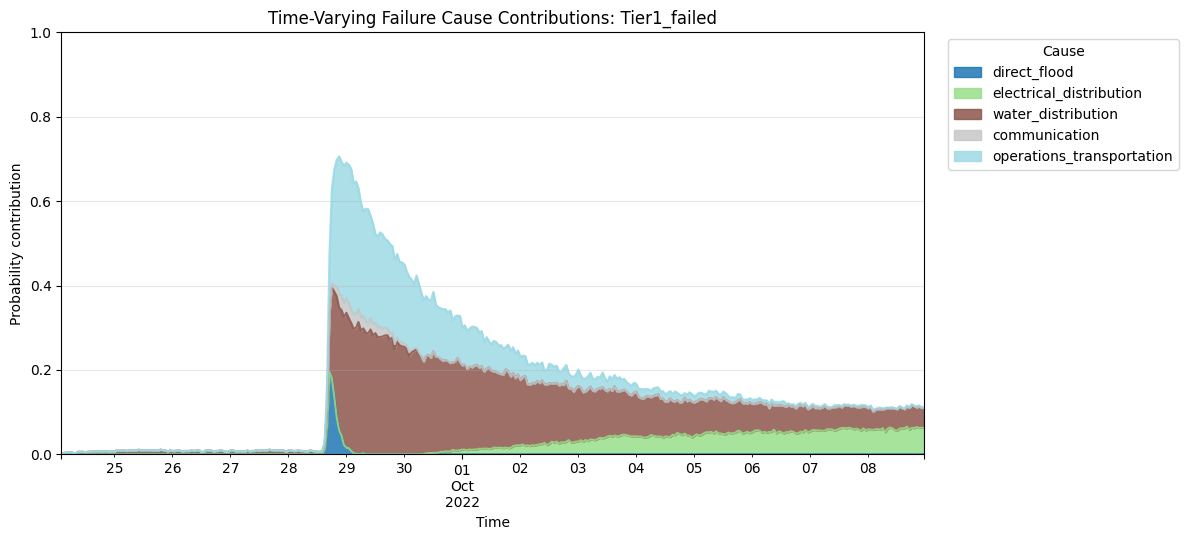

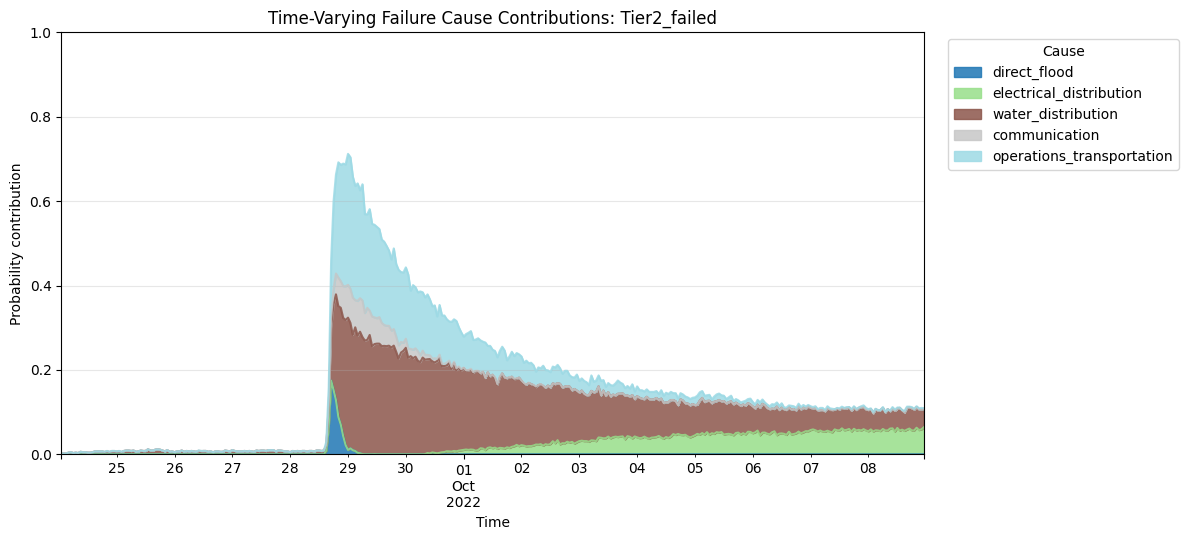

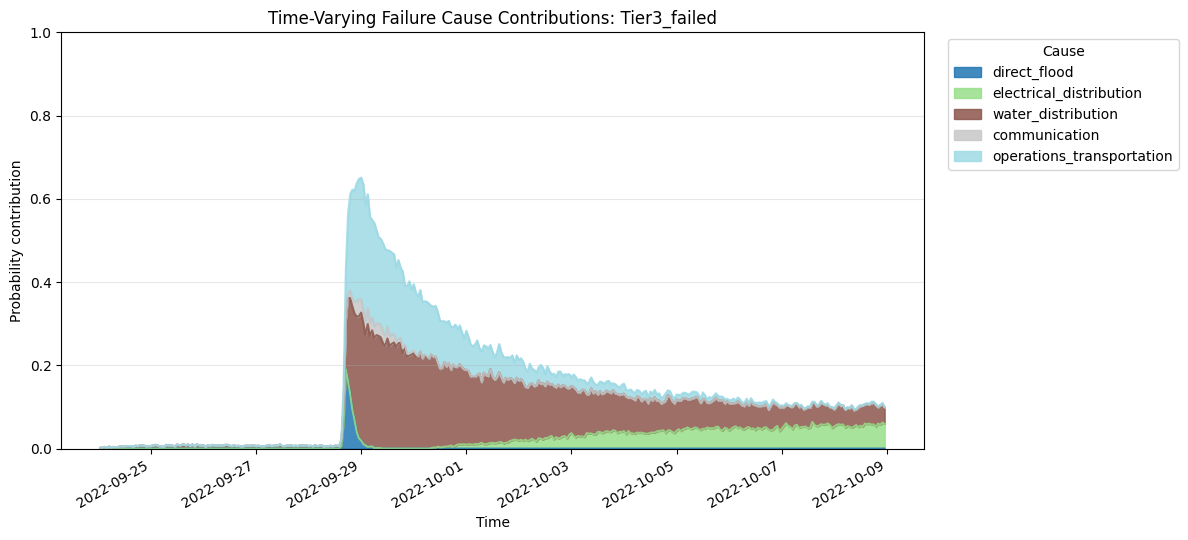

In [28]:
# ---------------------------------------------------------------------
# Plot time-varying cause composition for each tier
# ---------------------------------------------------------------------

if not tier_cause_time_summary.empty:
    cause_order = [
        "direct_flood",
        "electrical_distribution",
        "water_distribution",
        "communication",
        "operations_transportation",
        "generator_runtime_expired",
        "routine",
    ]

    for tier in ["Tier1_failed", "Tier2_failed", "Tier3_failed"]:
        df_tier_causes = tier_cause_time_summary[
            tier_cause_time_summary["tier"] == tier
        ].copy()

        cause_time_pivot = (
            df_tier_causes
            .pivot_table(
                index="time_local",
                columns="cause",
                values="cause_probability_contribution",
                aggfunc="sum",
            )
            .fillna(0.0)
            .sort_index()
        )

        ordered_columns = [
            cause for cause in cause_order
            if cause in cause_time_pivot.columns
        ]
        remaining_columns = [
            cause for cause in cause_time_pivot.columns
            if cause not in ordered_columns
        ]

        cause_time_pivot = cause_time_pivot[
            ordered_columns + remaining_columns
        ]

        ax = cause_time_pivot.plot(
            kind="area",
            stacked=True,
            figsize=(12, 5.5),
            alpha=0.85,
            colormap="tab20",
        )

        ax.set_xlabel("Time")
        ax.set_ylabel("Probability contribution")
        ax.set_ylim(0, 1)
        ax.set_title(f"Time-Varying Failure Cause Contributions: {tier}")
        ax.grid(axis="y", alpha=0.3)
        plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Cause")
        plt.tight_layout()
        plt.show()


## Inference under uncertainty

https://www.sciencedirect.com/science/article/pii/S095183200200056X#SEC8

Epistemic uncertainty analysis is an essential feature of any model application subject to ‘state of knowledge’ uncertainties. Such analysis is usually carried out on the basis of a Monte Carlo simulation sampling the epistemic variables and performing the corresponding model runs.

In situations, however, where aleatory uncertainties are also present in the model, an adequate treatment of both types of uncertainties would require a two-stage nested Monte Carlo simulation, i.e. sampling the epistemic variables (‘outer loop’) and nested sampling of the aleatory variables (‘inner loop’). It is clear that for complex and long running codes the computational effort to perform all the resulting model runs may be prohibitive.

### Our case

- Epistemic outer-loop variables:
    - fragility curve parameters
    - dependency strengths
    - recovery-time parameters

- Aleatory inner-loop variables:
    - whether each node fails at each timestamp
    - whether recovery occurs
    - whether noisy-OR parent causes trigger failure

- Scenario: a structured assumption set
- Outer loop: sample uncertain parameters
- Inner loop: run DBN state simulation under that sampled parameter set

### Uncertainty groups & scenarios

1. Fragility uncertainty
   - x_low_ft, p_low, x_high_ft, p_high by category

2. Dependency strength uncertainty
   - WaterDistribution_failed:
       - WTP_1_failed strength
       - ElectricalDistribution_failed strength

   - Tier1_failed:
       - electrical, water, communication, operations strengths
   - Tier2_failed:
       - electrical, water, communication, operations strengths
   - Tier3_failed:
       - electrical, water, communication, operations strengths

3. Recovery uncertainty
    - mean_recovery_hours_accessible by category
    - h_caution_ft
    - h_blocked_ft

We do not know the exact parameter values, but instead of assigning one broad undifferentiated uncertainty range, we evaluate structured vulnerability scenarios and propagate residual parameter uncertainty within each scenario.

| Scenario | Fragility | Dependency | Recovery | Interpretation |
|---|---|---|---|---|
| Optimistic resilience | Lower fragility | Weaker dependency | Faster recovery | Assets are protected, redundancy works well |
| Baseline | Current settings | Current settings | Current settings | Central model |
| High vulnerability | Higher fragility | Stronger dependency | Slower recovery | Systems are more exposed and tightly coupled |
| High fragility only | Higher fragility | Baseline dependency | Baseline recovery | Tests sensitivity to flood damage curves |
| High dependency only | Baseline fragility | Stronger dependency | Baseline recovery | Tests cascading dependency assumptions |
| Slow recovery only | Baseline fragility | Baseline dependency | Slower recovery | Tests persistence/recovery assumptions |

Workflow:

1. Define scenario families.
2. For each scenario:
      a. Sample epistemic parameters inside that scenario’s narrowed ranges.
      b. For each sampled parameter set:
             run DBN Monte Carlo trajectories.
      c. Summarize Tier 1/2/3 failure probability.
3. Compare scenarios:
      - median curve
      - 5-95% uncertainty band
      - peak failure probability
      - cause composition

Implication:
- Decide when move patients